Train 3 classifiers (dummy, logistic regression, random forest) on Lumen churn data. Evaluate and decide which to ship.

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [76]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [77]:
X_train = pd.read_parquet("X_train.parquet")
X_test = pd.read_parquet("X_test.parquet")
y_train = pd.read_parquet("y_train.parquet").iloc[:, 0]
y_test = pd.read_parquet("y_test.parquet").iloc[:, 0]

In [78]:
# dummy baseline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
print(classification_report(y_test, dummy.predict(X_test)))

              precision    recall  f1-score   support

       False       0.89      1.00      0.94      5329
        True       0.00      0.00      0.00       671

    accuracy                           0.89      6000
   macro avg       0.44      0.50      0.47      6000
weighted avg       0.79      0.89      0.84      6000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


predict() predicts actual class

predict_proba() predicts class probabilities (more relevant in business contexts)

In [103]:
# dummy ROC-AUC & PR-AUC
dummy_roc_auc = roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])
dummy_pr_auc = average_precision_score(y_test, dummy.predict_proba(X_test)[:, 1])

print(f"Dummy ROC_AUC: {dummy_roc_auc}")
print(f"Dummy PR_AUC: {dummy_pr_auc:.2f}")

Dummy ROC_AUC: 0.5
Dummy PR_AUC: 0.11


Dummy ROC_AUC (0.5): Model is as good as random

PR_AUC (0.11) : Low score, more informative than ROC for imbalanced problems

All other models should perform better than the dummy baseline.

In [104]:
# logistic regression with proper scaling

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, C=1.0, random_state=42))
])

lr_pipe.fit(X_train, y_train)
print(classification_report(y_test, lr_pipe.predict(X_test)))

              precision    recall  f1-score   support

       False       0.89      1.00      0.94      5329
        True       0.54      0.02      0.04       671

    accuracy                           0.89      6000
   macro avg       0.71      0.51      0.49      6000
weighted avg       0.85      0.89      0.84      6000



In [105]:
lr_roc_auc = roc_auc_score(y_test, lr_pipe.predict_proba(X_test)[:, 1])
lr_pr_auc = average_precision_score(y_test, lr_pipe.predict_proba(X_test)[:, 1])

print(f"Linear Regression ROC_AUC: {lr_roc_auc:.2f}")
print(f"Linear Regression PR_AUC {lr_pr_auc:.2f}")

Linear Regression ROC_AUC: 0.73
Linear Regression PR_AUC 0.28


Improved AUC with logistic regression model compared to dummy ^

In [82]:
# random forest
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(
    n_estimators = 200, # number of trees
    max_depth = None, # allow trees to grow fully (overfitting minimized by averaging)
    min_samples_leaf=5, # smallest leaf size to guard against noisy splits
    n_jobs = 1, # use all CPU cores
    random_state=42,
)

rf_clf.fit(X_train, y_train)

print(classification_report(y_test, rf_clf.predict(X_test)))

              precision    recall  f1-score   support

       False       0.89      1.00      0.94      5329
        True       0.33      0.00      0.01       671

    accuracy                           0.89      6000
   macro avg       0.61      0.50      0.47      6000
weighted avg       0.83      0.89      0.84      6000



In [100]:
rf_roc_auc = roc_auc_score(y_test, rf_clf.predict_proba(X_test)[:, 1])
rf_pr_auc = average_precision_score(y_test, rf_clf.predict_proba(X_test)[:, 1])
print(f"Random Forest ROC_AUC: {rf_roc_auc:.2f}")
print(f"Random Forest PR_AUC: {rf_pr_auc:.2f}")

Random Forest ROC_AUC: 0.71
Random Forest PR_AUC: 0.25


Improved AUC with random forest model compared to dummy ^, similar values to LR

In [107]:
# single test-set models have variance - run cross-validation (5-fold)
from sklearn.model_selection import cross_val_score

lr_cv = cross_val_score(lr_pipe, X_train, y_train, cv=5, scoring='average_precision')
rf_cv = cross_val_score(rf_clf, X_train, y_train, cv=5, scoring='average_precision')

print(f'LR PR_AUC: {lr_cv.mean():.3f} +/- {lr_cv.std():.3f}')
print(f'RF PR_AUC: {rf_cv.mean():.3f} +/- {rf_cv.std():.3f}')


LR PR_AUC: 0.286 +/- 0.012
RF PR_AUC: 0.254 +/- 0.010


Logistic Regression has slightly improved PR_AUC score (although difference may be negligible) / LR may be favored for simplicity

In [85]:
# save figures to 'clt_figures' dir
import os

os.makedirs("clf_figures", exist_ok=True)

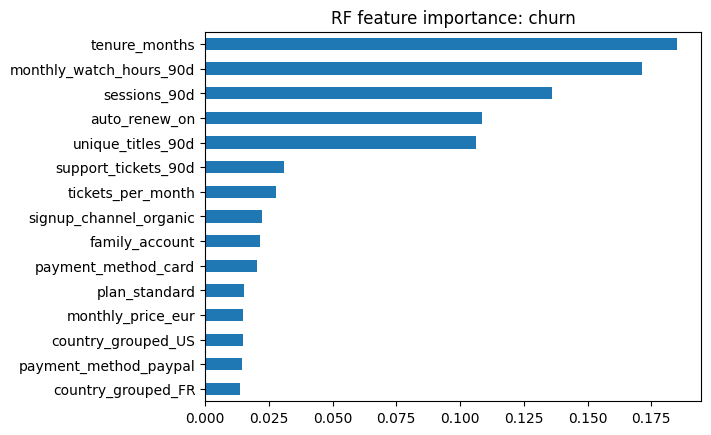

In [108]:
# random forest feature importance
importance = pd.Series(rf_clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importance.head(15).sort_values().plot(kind="barh")

plt.title("RF feature importance: churn")
plt.savefig("clf_figures/rf_importance.png", bbox_inches="tight")

Top 5 most important features by random forest:

tenure_months

monthly_watch_hours_90d

sessions_90d

auto_renew_on

unique_titles_90d

In [87]:
# logistic regression feature importance (standardized coefficients)

coefs = pd.Series(lr_pipe.named_steps["clf"].coef_[0], index=X_train.columns).abs().sort_values(ascending=False)
print(coefs.head(15))

auto_renew_on               0.501062
tenure_months               0.492019
family_account              0.194858
support_tickets_90d         0.172855
tickets_per_month           0.172855
monthly_watch_hours_90d     0.165608
signup_channel_organic      0.142860
payment_method_gift_card    0.123505
sessions_90d                0.094667
signup_channel_referral     0.093687
country_grouped_US          0.084594
country_grouped_BR          0.071181
signup_channel_app_store    0.066879
country_grouped_FR          0.065520
country_grouped_DE          0.062348
dtype: float64


Top 5 most important features by logistic regression:

auto_renew_on

tenure_months

family_account

support_tickets_90d

tickets_per_month

Overlapping features (RF + LR): auto_renew_on, tenure_months

In [101]:
# threshold tuning
lr_probs = lr_pipe.predict_proba(X_test)[:, 1]
rf_probs = rf_clf.predict_proba(X_test)[:, 1]

# Sort descending, take top 400 (~7% of 6000-row test set)
sorted_probs = np.sort(rf_probs)[::-1]

threshold = sorted_probs[399] # 400th highest prob

print(f"Threshold: {threshold:.3f}")

Threshold: 0.271


In [102]:
predictions_top = (rf_probs >= threshold).astype(int)

In [96]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, predictions_top)
recall = recall_score(y_test, predictions_top)
f1 = f1_score(y_test, predictions_top)

print(precision)
print(recall)
print(f1)


0.34
0.20268256333830104
0.25396825396825395


In [98]:
# compute metrics for LR (Default threshold), RF (Default threshold), RF(Top-400 Threshold)
metrics = {"Metrics": ["Precision", "Recall", "F1"]}
results_df = pd.DataFrame(metrics)

def compute_metrics(name, y_true, preds):
  precision = precision_score(y_true, preds)
  recall = recall_score(y_true, preds)
  f1 = f1_score(y_true, preds)

  metrics_dict = {"Precision" : precision,
                   "Recall": recall,
                   "F1": f1}

  results_df[name] = results_df["Metrics"].map(metrics_dict)
  return metrics_dict

compute_metrics("LR (Default 0.5)", y_test, lr_pipe.predict(X_test))
compute_metrics("RF (Default 0.5)", y_test, rf_clf.predict(X_test))
compute_metrics("RF (Top-400 Threshold)", y_test, predictions_top)

{'Precision': 0.34, 'Recall': 0.20268256333830104, 'F1': 0.25396825396825395}

In [99]:
results_df

,Metrics,LR (Default 0.5),RF (Default 0.5),RF (Top-400 Threshold)
0,Precision,0.535714,0.333333,0.340000
1,Recall,0.022355,0.002981,0.202683
2,F1,0.042918,0.005908,0.253968


Ship random forest model at top-400 threshold -- trades recall for precision and flags fewer total churners, but a higher % of those flagged are real.